Question 1: What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each ?

Answer

1. **K-Means Clustering**

K-Means is an iterative algorithm that tries to partition the dataset into k pre-defined distinct non-overlapping subgroups (clusters) where each data point belongs to only one group.
- How it works: It assigns data points to the nearest "centroid" (center of the cluster) and then recalculates the centroid based on the average of the points in that cluster. It repeats this until the centroids stop moving.
- Best for: Large datasets where you have a rough idea of how many groups you want and the groups are relatively distinct.

Use Case: Customer Segmentation (Retail)

A large e-commerce company wants to target marketing campaigns effectively. They have millions of customer records.

- Application: Using K-Means, they set $k=3$ to group customers based on "Annual Spending" and "Frequency of Purchase.

 Result: The algorithm quickly segments the 10 million users into three distinct buckets:
 1. High Spenders / Frequent (Target with loyalty programs).
 2. Moderate Spenders / Infrequent (Target with discount coupons).
 3. Low Spenders / Rare (Target with re-engagement emails).

 i.e. Why K-Means? The dataset is huge (millions of rows), and speed is more critical than understanding the hierarchical relationship between customers.

2. **Hierarchical Clustering**

Hierarchical clustering builds a hierarchy of clusters. It usually proceeds in a "bottom-up" manner (Agglomerative), where each data point starts in its own cluster, and pairs of clusters are merged as one moves up the hierarchy.

- How it works: It calculates the distance between every pair of data points and merges the closest ones. This process creates a tree diagram called a Dendrogram. You can "cut" the tree at different heights to decide how many clusters you want after the fact.
- Best for: Smaller datasets where understanding the structure or relationships between data points is important.


Use Case: Biological Taxonomy (Genetics)

Biologists want to understand how different animal species are related to one another based on their DNA sequences.
- Application: They run Hierarchical Clustering on the genetic data of 50 different species.

Result: The output is a Dendrogram.
1. At the bottom, "Lions" and "Tigers" merge first (very similar).
2. Higher up, that group merges with "House Cats.
3. Much higher up, the "Feline" group merges with the "Canine" group (Dogs/Wolves).

i.e. Why Hierarchical? The goal isn't just to put animals in buckets; it is to visualize the evolutionary path and see which species are sub-groups of others. K-Means cannot show this nested relationship.

Question 2: Explain the purpose of the Silhouette Score in evaluating clustering
algorithms ?

Answer

The **Silhouette Score** is a metric used to evaluate the quality of clusters created by algorithms like K-Means or Hierarchical Clustering.
Since clustering is "unsupervised" (we don't have the correct answers or labels to check against), we cannot calculate "accuracy." Instead, the Silhouette Score helps us measure how distinct and well-defined the clusters are.

It answers the question: "How similar is a data point to its own cluster compared to other clusters?

*How it Works (The Logic)*

The score is calculated for each data point using two distances:
1. Cohesion ($a$): The average distance between the data point and all other points in the same cluster. (We want this to be small).
2. Separation ($b$): The average distance between the data point and all points in the nearest neighboring cluster. (We want this to be large).

The Silhouette Coefficient ($s$) for a single point is given by:$$s = \frac{b - a}{\max(a, b)}$$

Question 3: What are the core parameters of DBSCAN, and how do they influence the clustering process?

Answer

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) differs from K-Means because it doesn't look for circular shapes or a specific number of clusters ($k$). Instead, it looks for areas of high density separated by areas of low density.

To define what "dense" means, DBSCAN relies on two critical parameters:
 **Epsilon **(eps) and **Minimum Samples**(min_samples).

 1. **Epsilon** (eps) - The Radius

This parameter defines the maximum distance between two data points for them to be considered "neighbors." You can think of this as drawing a circle (or hypersphere) with a radius of eps around a data point.

- *Function*: It establishes the "neighborhood" size.

- *Influence on Clustering*:
  - If **eps** is too small: The neighborhood is tiny. Many points won't find enough neighbors to form a cluster and will be labeled as "Noise" (outliers). You might get many tiny, fragmented clusters.

  - If **eps** is too large: The neighborhood is huge. It may bridge the gap between distinct clusters, merging them into one massive, uninformative blob.

2. **Minimum Samples**(min_samples) - The Density Threshold

This parameter defines how many neighbors (including the point itself) must be within the eps radius for a region to be considered "dense."

- *Function*: It establishes the minimum density required to form a cluster.

- *Influence on Clustering*:

  - If **min_samples** is too low: The algorithm becomes too lenient. It might group outlier points into valid clusters, creating "spurious" clusters from noise.

  - If **min_samples** is too high: The algorithm becomes too strict. Even valid, moderately dense clusters might be classified as noise because they don't meet the high count requirement.

**How They Work Together**

These two parameters determine the status of every data point:

1. Core Point: A point that has at least min_samples within its eps radius. (These form the heart of a cluster).

2. Border Point: A point that is within the eps radius of a Core Point but has fewer than min_samples itself. (These form the edge of the cluster).

3. Noise Point: A point that is neither a Core nor a Border point. (These are discarded as outliers).

Question 4: Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?

Answer

Feature scaling is critical because both K-Means and DBSCAN are distance-based algorithms. They typically use Euclidean distance to determine which data points are "close" or "similar" to each other.

If features are not scaled to a similar range (e.g., using Standardization or Normalization), the feature with the larger magnitude will dominate the distance calculation, causing the algorithm to ignore smaller-scale features.

*The Problem: Magnitude Bias*

Imagine clustering customers based on two features:
1. Annual Income: Range 20,000 to 100,000 (Spread: 80,000)
2. Age: Range 18 to 70 (Spread: 52)
Mathematically, a difference of 5 years in age ($5^2 = 25$) is negligible compared to a difference of $5,000 in income ($5000^2 = 25,000,000$).
  - Without Scaling: The algorithm will cluster users almost entirely based on Income. Age becomes irrelevant.
  
  - With Scaling: Both Income and Age contribute equally to the distance calculation.

*Impact on Algorithms*

- K-Means: K-Means assumes clusters are spherical (round). If data isn't scaled, the clusters will be elongated ellipses. The algorithm will struggle to find the true center (centroid), leading to poor convergence and inaccurate groupings.

- DBSCAN: This algorithm uses a fixed radius (eps) to find neighbors. If one axis is stretched (e.g., Income) and the other is compressed (e.g., Age), the "neighborhood" circle effectively becomes a thin slit, capturing neighbors only along the high-magnitude axis and failing to detect density correctly.

Question 5: What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?

Answer

The Elbow Method is the most common heuristic (rule of thumb) used to determine the optimal number of clusters ($k$) in K-Means clustering.

Since K-Means requires you to specify $k$ before you run the algorithm, the Elbow Method allows you to run the algorithm multiple times (e.g., for $k=1$ to $k=10$) and graphically assess which $k$ provides the best balance between cluster compactness and computational efficiency.

1. The Metric: WCSS (Inertia)

To find the "elbow," we calculate the Within-Cluster Sum of Squares (WCSS), also known as Inertia, for each value of $k$.
- What it measures: The sum of the squared distances between each data point and the centroid of its assigned cluster.
- Goal: We want WCSS to be low, which means the data points are very close to their centroids (the clusters are tight and compact).

2. The Trade-off

There is a catch: WCSS will always decrease as $k$ increases.
- If $k=1$, WCSS is at its maximum (one huge cluster).
- If $k = \text{number of data points}$, WCSS is 0 (every point is its own cluster).

We cannot simply pick the lowest WCSS. We need to find the point where adding another cluster gives diminishing returns.

3. Interpreting the Plot (Finding the "Elbow")

When you plot the number of clusters ($k$) on the x-axis and WCSS on the y-axis, the graph typically looks like an arm bending.
- Steep Drop: For small values of $k$, increasing the number of clusters leads to a massive drop in WCSS. This means the new clusters are effectively splitting large, distinct groups.
- The "Elbow" Point: This is the point of inflection where the curve bends. It represents the optimal $k$.
- Plateau: After the elbow, increasing $k$ further decreases WCSS only marginally. This suggests you are no longer splitting distinct groups, but rather splitting valid clusters into smaller, unnecessary fragments (overfitting).


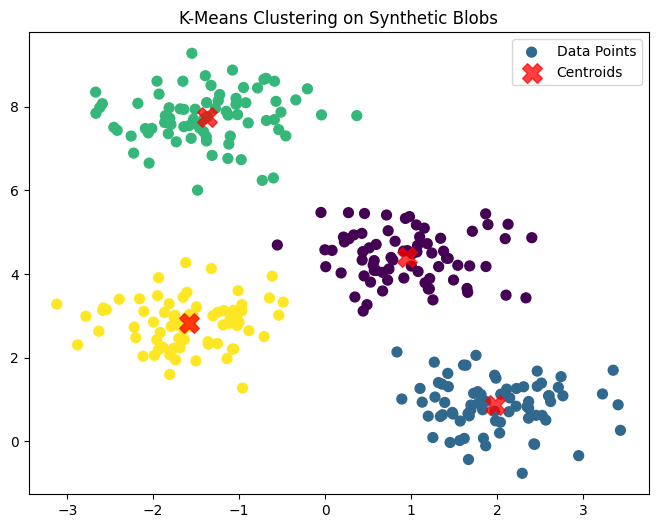

In [8]:
'''
Question 6: Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers?
'''

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data
# [cite: 27] n_samples=300, centers=4
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# 3. Visualize results with cluster centers
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data Points')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering on Synthetic Blobs")
plt.legend()
plt.show()

In [9]:
'''
Question 7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise)?
'''

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Load the Wine dataset [cite: 30]
wine = load_wine()
X = wine.data

# 2. Apply StandardScaler [cite: 30]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train DBSCAN model
# Note: eps and min_samples may need tuning.
# Using distinct parameters to ensure clusters are found.
dbscan = DBSCAN(eps=2.5, min_samples=4)
labels = dbscan.fit_predict(X_scaled)

# 4. Print number of clusters (excluding noise which is labeled -1) [cite: 31]
# We count unique labels and subtract 1 if noise (-1) is present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

Estimated number of clusters: 1
Estimated number of noise points: 23


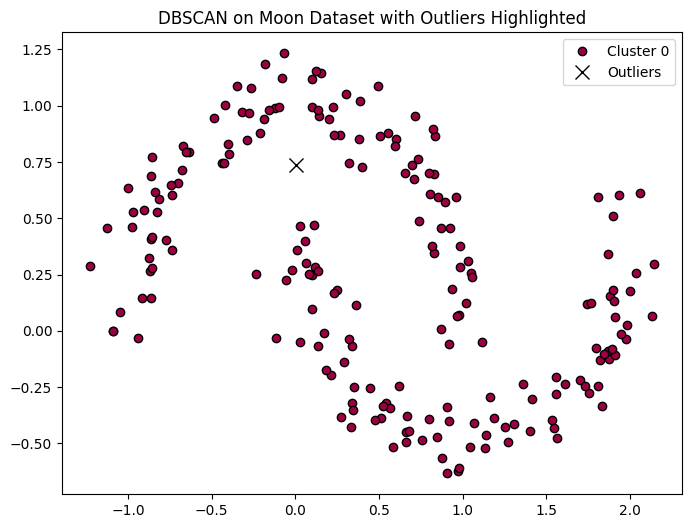

In [10]:
'''
Question 8: Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot ?
'''

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# 1. Generate moon-shaped synthetic data
X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)

# 2. Apply DBSCAN
# eps is set to 0.25 to detect the moon shape while leaving some outliers
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Highlight outliers in the plot
# Outliers are labeled as -1 by DBSCAN
plt.figure(figsize=(8, 6))

# Plot clusters
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise/outliers
        col = [0, 0, 0, 1]
        label_text = "Outliers"
        marker = 'x'
    else:
        label_text = f"Cluster {k}"
        marker = 'o'

    class_member_mask = (labels == k)

    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10 if k == -1 else 6, label=label_text)

plt.title('DBSCAN on Moon Dataset with Outliers Highlighted')
plt.legend()
plt.show()

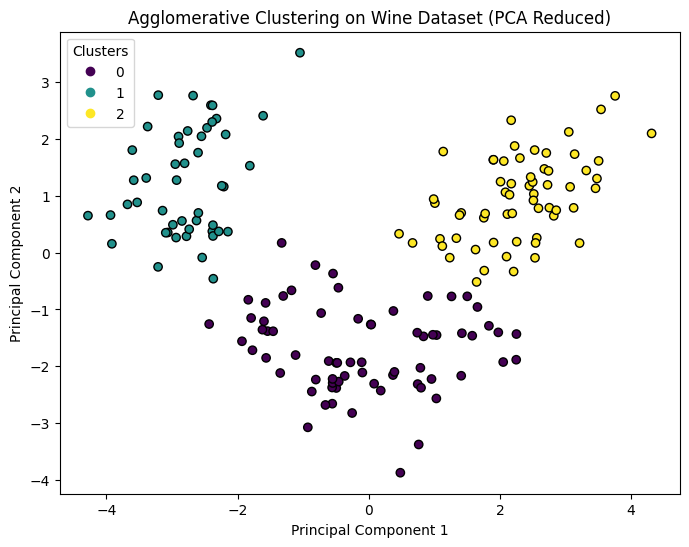

In [11]:
'''
Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot ?
'''

import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# 1. Load Data
wine = load_wine()
X = wine.data

# 2. Preprocessing (Standard Scaling is crucial before PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Apply Agglomerative Clustering
# We assume 3 clusters as there are 3 classes in the original Wine dataset
agg_cluster = AgglomerativeClustering(n_clusters=3)
labels = agg_cluster.fit_predict(X_pca)

# 5. Visualize result in 2D with a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.title("Agglomerative Clustering on Wine Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

Question 10: You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run targeted promotions. The dataset contains customer demographics and their product purchase history across categories.

Describe your real-world data science workflow using clustering:

- Which clustering algorithm(s) would you use and why?
- How would you preprocess the data (missing values, scaling)?
- How would you determine the number of clusters?
- How would the marketing team benefit from your clustering analysis?

Answer

**E-commerce Customer Segmentation Workflow**

A . Algorithm Selection: K-Means Clustering

For e-commerce customer segmentation, K-Means Clustering is the industry standard and my primary choice.
- Scalability: E-commerce datasets often have millions of rows. K-Means has a time complexity of $O(n)$, making it significantly faster than Hierarchical Clustering ($O(n^2)$).
- Interpretability: Marketing teams need clear, distinct personas (e.g., "High Spenders"). K-Means creates non-overlapping partitions that are easy to explain to non-technical stakeholders.
- Actionability: It is computationally cheap to assign new customers to these established clusters in real-time.


B . Data Preprocessing

Data quality determines cluster quality. My preprocessing pipeline would include:

1. Feature Engineering (RFM): Raw transaction logs are not cluster-ready. I would aggregate them into RFM metrics:
- Recency: Days since last purchase.
- Frequency: Total number of transactions.
- Monetary: Total distinct spend.

2. Handling Missing Values:
- Numerical: Impute with the Median to avoid skewing the centroid with outliers.
- Categorical: Create a separate "Unknown" category or use Mode imputation.

3. Feature Scaling (Crucial):
- K-Means uses Euclidean distance to measure similarity. If one feature has a large range (e.g., Income: 0–100k) and another is small (e.g., Frequency: 0–10), the algorithm will be biased toward Income.

- Action: Apply StandardScaler (Z-score normalization) to bring all features to a mean of 0 and variance of 1.

C . Determining the Number of Clusters ($k$)

I would use a combination of statistical methods and business logic:

- The Elbow Method: Plot the Inertia (Within-Cluster Sum of Squares) against different values of $k$. I look for the "elbow" point where the decrease in inertia slows down significantly.
- Silhouette Analysis: Calculate the Silhouette Score for the chosen $k$ to ensure the clusters are dense and well-separated.
- Business Validation: If the math suggests $k=15$ but the marketing team only has resources for 3 campaigns, I would constrain $k$ to a manageable number (e.g., 3-5).


D . Business Benefits for Marketing

The clustering analysis translates directly into ROI:

- Churn Prevention: Identify the "High Value, Low Recency" cluster (customers who spent a lot but haven't visited lately) and target them with "We miss you" offers.

- Budget Optimization: Stop spending ad money on the "Loyalists" (who buy anyway) and redirect it to "Potential Loyalists."

- Inventory Planning: Use "Category Preference" clusters to stock the right products for the right demographic.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ==========================================
# 1. DATA GENERATION (Mock E-commerce Data)
# ==========================================
np.random.seed(42)
data = {
    'CustomerID': range(1, 201),
    # Annual Income in $
    'Annual_Income': np.random.randint(20000, 140000, 200),
    # Spending Score (1-100), assigned based on behavior
    'Spending_Score': np.random.randint(1, 100, 200),
    # Age of the customer
    'Age': np.random.randint(18, 70, 200)
}
df = pd.DataFrame(data)

# ==========================================
# 2. PREPROCESSING
# ==========================================
# Select features for clustering (exclude IDs)
features = ['Annual_Income', 'Spending_Score', 'Age']
X = df[features]

# SCALING: Standardize features to have mean=0 and variance=1
# This prevents 'Income' from dominating 'Spending Score' due to larger magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. DETERMINE OPTIMAL CLUSTERS (Elbow Method)
# ==========================================
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualization of Elbow Method (usually plotted here)
# Based on this mock data, let's assume the optimal k is 5

# ==========================================
# 4. MODEL TRAINING & PREDICTION
# ==========================================
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Append cluster labels back to original dataframe for interpretation
df['Cluster'] = clusters

# ==========================================
# 5. BUSINESS INTERPRETATION
# ==========================================
# Group by Cluster to see the "Profile" of each segment
analysis = df.groupby('Cluster')[['Annual_Income', 'Spending_Score', 'Age']].mean()

print("--- Customer Segments Profile ---")
print(analysis)

print("\n--- Marketing Recommendations ---")
# Example logic to automate recommendations based on cluster averages
for cluster_id in range(optimal_k):
    avg_spend = analysis.loc[cluster_id, 'Spending_Score']
    avg_income = analysis.loc[cluster_id, 'Annual_Income']

    if avg_spend > 75 and avg_income > 80000:
        print(f"Cluster {cluster_id}: 'VIP Whales' -> Action: Premium Membership Offer.")
    elif avg_spend < 40 and avg_income > 80000:
        print(f"Cluster {cluster_id}: 'Frugal Wealthy' -> Action: Upsell/Brand Awareness Ads.")
    elif avg_spend > 70 and avg_income < 40000:
        print(f"Cluster {cluster_id}: 'Young Spenders' -> Action: Buy-Now-Pay-Later Promos.")

--- Customer Segments Profile ---
         Annual_Income  Spending_Score        Age
Cluster                                          
0        110904.585366       51.560976  28.268293
1         85266.452381       76.547619  59.214286
2        104627.979167       24.000000  52.687500
3         39586.974359       29.153846  44.230769
4         54925.966667       85.500000  32.433333

--- Marketing Recommendations ---
Cluster 1: 'VIP Whales' -> Action: Premium Membership Offer.
Cluster 2: 'Frugal Wealthy' -> Action: Upsell/Brand Awareness Ads.
